In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

In [ ]:
base_path="/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT"

train_images=os.path.join(base_path,"train/images")
train_labels=os.path.join(base_path,"train/labels")

val_images=os.path.join(base_path,"val/images")
val_labels=os.path.join(base_path,"val/labels")

print("Dataset Loaded Successfully")

In [ ]:
print("="*60)

print("Training Images :",len(os.listdir(train_images)))
print("Training Labels :",len(os.listdir(train_labels)))

print()

print("Validation Images :",len(os.listdir(val_images)))
print("Validation Labels :",len(os.listdir(val_labels)))

print("="*60)

In [ ]:
class_names={
    0:"Longitudinal_Crack",
    1:"Transverse_Crack",
    2:"Alligator_Crack",
    3:"Pothole",
    4:"Repair_Other"
}

print(class_names)

In [ ]:
output_path="/kaggle/working/processed_dataset"

os.makedirs(output_path,exist_ok=True)

print(output_path)

In [ ]:
for folder in class_names.values():

    os.makedirs(os.path.join(output_path,folder),exist_ok=True)

print("All Class Folders Created Successfully")

In [ ]:
print("Folders Inside Processed Dataset:\n")

for folder in os.listdir(output_path):

    print(folder)

In [ ]:
print("="*60)

print("Training Images :",len(os.listdir(train_images)))
print("Training Labels :",len(os.listdir(train_labels)))

print()

print("Output Folder :",output_path)

print("="*60)

In [ ]:
print("="*60)

print("Notebook 2.5 Ready")

print()

print("Next Step")

print("✔ Read YOLO Labels")

print("✔ Convert Coordinates")

print("✔ Crop Damage")

print("✔ Save Images")

print("="*60)

In [ ]:
def load_yolo_labels(label_path):

    annotations=[]

    with open(label_path,"r") as file:

        for line in file.readlines():

            data=line.strip().split()

            class_id=int(data[0])

            x_center=float(data[1])
            y_center=float(data[2])
            width=float(data[3])
            height=float(data[4])

            annotations.append(
                [
                    class_id,
                    x_center,
                    y_center,
                    width,
                    height
                ]
            )

    return annotations

In [ ]:
def convert_yolo_bbox(
    annotation,
    img_width,
    img_height
):

    class_id,x,y,w,h=annotation


    x*=img_width
    y*=img_height

    w*=img_width
    h*=img_height


    x1=int(x-w/2)
    y1=int(y-h/2)

    x2=int(x+w/2)
    y2=int(y+h/2)


    return class_id,x1,y1,x2,y2

In [ ]:
sample_label=None

for file in os.listdir(train_labels):

    path=os.path.join(train_labels,file)

    annotations=load_yolo_labels(path)

    if len(annotations)>0:
        sample_label=path
        break


print("Selected Label:")
print(sample_label)


annotations=load_yolo_labels(sample_label)


print()
print("Objects Found:")
print(len(annotations))

print(annotations)

In [ ]:
def crop_damage_region(
    image,
    annotation
):

    height,width=image.shape[:2]


    class_id,x1,y1,x2,y2 = convert_yolo_bbox(
        annotation,
        width,
        height
    )


    x1=max(0,x1)
    y1=max(0,y1)

    x2=min(width,x2)
    y2=min(height,y2)


    crop=image[y1:y2,x1:x2]


    return class_id,crop

In [ ]:
if len(annotations)>0:

    class_id,crop=crop_damage_region(
        image,
        annotations[0]
    )

    plt.figure(figsize=(5,5))

    plt.imshow(
        cv2.cvtColor(
            crop,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.axis("off")

    plt.title(
        class_names[class_id]
    )

    plt.show()

else:

    print("No Damage Object Found")

In [ ]:
IMAGE_SIZE=224


def resize_crop(image):

    return cv2.resize(
        image,
        (IMAGE_SIZE,IMAGE_SIZE)
    )

In [ ]:
def save_processed_image(
    image,
    class_id,
    index
):

    folder=os.path.join(
        output_path,
        class_names[class_id]
    )


    file_path=os.path.join(
        folder,
        f"damage_{index}.jpg"
    )


    cv2.imwrite(
        file_path,
        image
    )

In [ ]:
image_counter=0


for image_name in tqdm(
    os.listdir(train_images)
):

    if image_name.endswith(".jpg"):


        img_path=os.path.join(
            train_images,
            image_name
        )


        label_name=image_name.replace(
            ".jpg",
            ".txt"
        )


        label_path=os.path.join(
            train_labels,
            label_name
        )


        if os.path.exists(label_path):


            image=cv2.imread(img_path)


            labels=load_yolo_labels(
                label_path
            )


            for label in labels:


                class_id,crop=crop_damage_region(
                    image,
                    label
                )


                if crop.size!=0:


                    crop=resize_crop(
                        crop
                    )


                    save_processed_image(
                        crop,
                        class_id,
                        image_counter
                    )


                    image_counter+=1

In [24]:
print("="*60)
print("PROCESSED TRAIN DATASET SUMMARY")
print("="*60)

train_class_counts = {}

for folder in class_names.values():
    folder_path = os.path.join(output_path, folder)
    count = len(os.listdir(folder_path))
    train_class_counts[folder] = count
    print(f"{folder:20s} : {count}")

print("="*60)
print("Total Processed Train Images :", sum(train_class_counts.values()))

PROCESSED TRAIN DATASET SUMMARY
Longitudinal_Crack   : 18201
Transverse_Crack     : 8386
Alligator_Crack      : 7526
Pothole              : 7554
Repair_Other         : 4628
Total Processed Train Images : 46295


In [25]:
val_output_path = "/kaggle/working/processed_dataset_val"

os.makedirs(val_output_path, exist_ok=True)

for folder in class_names.values():
    os.makedirs(os.path.join(val_output_path, folder), exist_ok=True)

print("Validation Output Folders Created")

Validation Output Folders Created


In [28]:
def save_processed_image_v2(image, class_id, index, base_path):

    folder = os.path.join(base_path, class_names[class_id])
    file_path = os.path.join(folder, f"damage_{index}.jpg")
    cv2.imwrite(file_path, image)

In [27]:
val_image_counter = 0

for image_name in tqdm(os.listdir(val_images)):

    if image_name.endswith(".jpg"):

        img_path = os.path.join(val_images, image_name)
        label_name = image_name.replace(".jpg", ".txt")
        label_path = os.path.join(val_labels, label_name)

        if os.path.exists(label_path):

            image = cv2.imread(img_path)
            labels = load_yolo_labels(label_path)

            for label in labels:

                class_id, crop = crop_damage_region(image, label)

                if crop.size != 0:
                    crop = resize_crop(crop)
                    save_processed_image_v2(crop, class_id, val_image_counter, val_output_path)
                    val_image_counter += 1

print("Validation Processing Done. Total Crops:", val_image_counter)

100%|██████████| 5758/5758 [02:53<00:00, 33.28it/s]

Validation Processing Done. Total Crops: 9741


In [29]:
print("="*60)
print("PROCESSED VALIDATION DATASET SUMMARY")
print("="*60)

val_class_counts = {}

for folder in class_names.values():
    folder_path = os.path.join(val_output_path, folder)
    count = len(os.listdir(folder_path))
    val_class_counts[folder] = count
    print(f"{folder:20s} : {count}")

print("="*60)

PROCESSED VALIDATION DATASET SUMMARY
Longitudinal_Crack   : 3890
Transverse_Crack     : 1769
Alligator_Crack      : 1553
Pothole              : 1564
Repair_Other         : 965


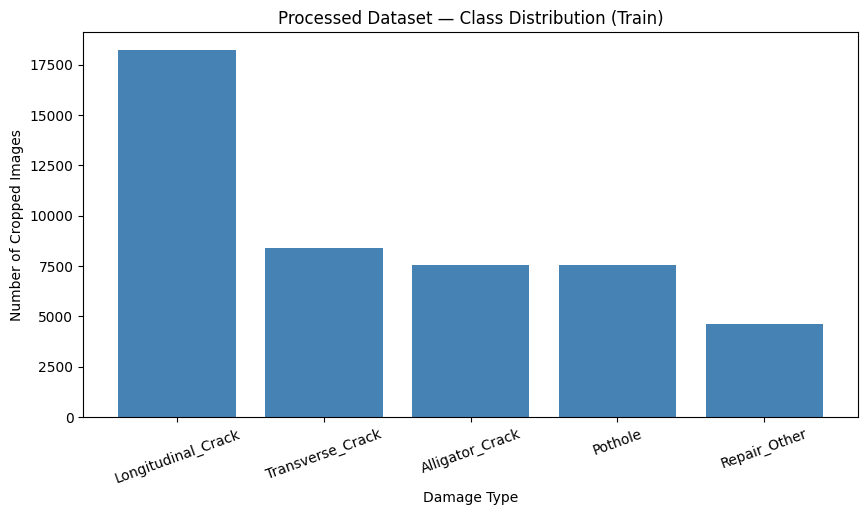

In [30]:
plt.figure(figsize=(10,5))
plt.bar(train_class_counts.keys(), train_class_counts.values(), color='steelblue')
plt.title("Processed Dataset — Class Distribution (Train)")
plt.xlabel("Damage Type")
plt.ylabel("Number of Cropped Images")
plt.xticks(rotation=20)
plt.show()

# Notebook 2.5 Completed

✔ YOLO labels converted to bounding boxes
✔ Damage regions cropped from original images
✔ Cropped images resized to 224×224
✔ Train images processed and saved class-wise
✔ Validation images processed and saved class-wise
✔ Dataset ready for CNN training

Output:
- /kaggle/working/processed_dataset/  (train)
- /kaggle/working/processed_dataset_val/  (validation)

Next Notebook: Notebook 3 → CNN Model (EfficientNetB0 Transfer Learning)